In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)
import xgboost as xgb
import lightgbm as lgb
import optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)


warnings.filterwarnings("ignore")
print(" ALL IMPORTS SUCESSFUL")

 ALL IMPORTS SUCESSFUL


In [2]:
X_train=joblib.load("../data/processed/X_train.pkl")
y_train=joblib.load("../data/processed/y_train.pkl")
X_val=joblib.load("../data/processed/X_val.pkl")
y_val=joblib.load("../data/processed/y_val.pkl")
X_test=joblib.load("../data/processed/X_test.pkl")
y_test=joblib.load("../data/processed/y_test.pkl")
print()
print("DATA LOADED SUCESSFULLY!")
print(f"TRAIN SHAPE  :  {X_train.shape}  | FRAUD: {y_train.sum():,}({y_train.mean()*100:.1f}%)")
print(f"VAL SHAPE    :  {X_val.shape}    | FRAUD: {y_val.sum():,}({y_val.mean()*100:.3f}%)")
print(f"TEST SHAPE   :  {X_test.shape}   | FRAUD: {y_test.sum():,}({y_test.mean()*100:.3f}%)")
      



DATA LOADED SUCESSFULLY!
TRAIN SHAPE  :  (374612, 31)  | FRAUD: 187,306(50.0%)
VAL SHAPE    :  (40215, 31)    | FRAUD: 70(0.174%)
TEST SHAPE   :  (56962, 31)   | FRAUD: 98(0.172%)


BUILDING EVALUATION MODEL

In [3]:
def evaluate_model(name,model,X_val,y_val):
    """
    Evaluates a trained model and returns a results dictionary.
    Uses AUC-ROC and F1 — not accuracy (useless on imbalanced data).
    """

    y_pred=model.predict(X_val)
    y_prob=model.predict_proba(X_val)[:,1]


    auc=roc_auc_score(y_val, y_prob)
    f1=f1_score(y_val,y_pred)
    avg_prec=average_precision_score(y_val,y_prob)
     
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC              :{auc:.4f}")
    print(f"  F1 SCORE             :{f1:.4f}")
    print(f"  AVERAGE PRECISION    :{avg_prec:.4f}")


    return{
        "name"     :name,
        "model"    :model,
        "auc"      :auc,
        "f1"       :f1,
        "avg_prec" :avg_prec,
        "y_prob"   :y_prob,
        "y_pred"    :y_pred,
    }
        
print("EVALUATION FUNCTION READY!")

EVALUATION FUNCTION READY!


In [4]:
print("TRAINING LOGISTIC REGRESSION (baseline)...")
lr=LogisticRegression(max_iter=1000,random_state=42,n_jobs=-1)
lr.fit(X_train,y_train)
print("DONE!")

results_lr=evaluate_model("LOGISTIC REGERESSION(BASELINE)",lr,X_val,y_val)

TRAINING LOGISTIC REGRESSION (baseline)...
DONE!

  LOGISTIC REGERESSION(BASELINE)
  AUC-ROC              :0.9690
  F1 SCORE             :0.1019
  AVERAGE PRECISION    :0.6958


MODEL-2----> XGBOOST

In [5]:
print("TRAINING XGBOOST")
xgb_model=xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytetree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="auc",
    verbosity=0
)
xgb_model.fit(
    X_train,y_train,
    eval_set=[(X_val,y_val)],
    verbose=False
)

print("DONE!")
results_xgb=evaluate_model("XGBOOST",xgb_model,X_val,y_val)


TRAINING XGBOOST
DONE!

  XGBOOST
  AUC-ROC              :0.9688
  F1 SCORE             :0.7703
  AVERAGE PRECISION    :0.8173


MODEL-3 LIGHTGBM

In [6]:
print("TRAINING LIGHTGBM")
lgb_model=lgb.LGBMClassifier(
    n_estimators=300,
    Learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytetree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lgb_model.fit(
    X_train,y_train,
    eval_set=[(X_val,y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50,verbose=False),
               lgb.log_evaluation(period=0)]
)
print("DONE!")
results_lgb=evaluate_model("LIGHTGBM",lgb_model,X_val,y_val)

TRAINING LIGHTGBM
DONE!

  LIGHTGBM
  AUC-ROC              :0.9630
  F1 SCORE             :0.8182
  AVERAGE PRECISION    :0.8087


COMPARING ALL 3 MODELS

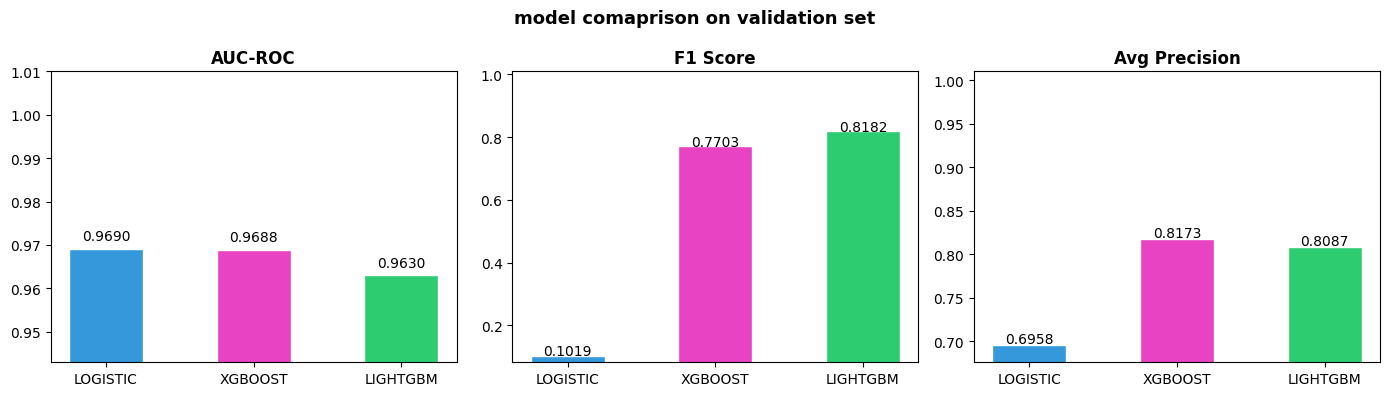

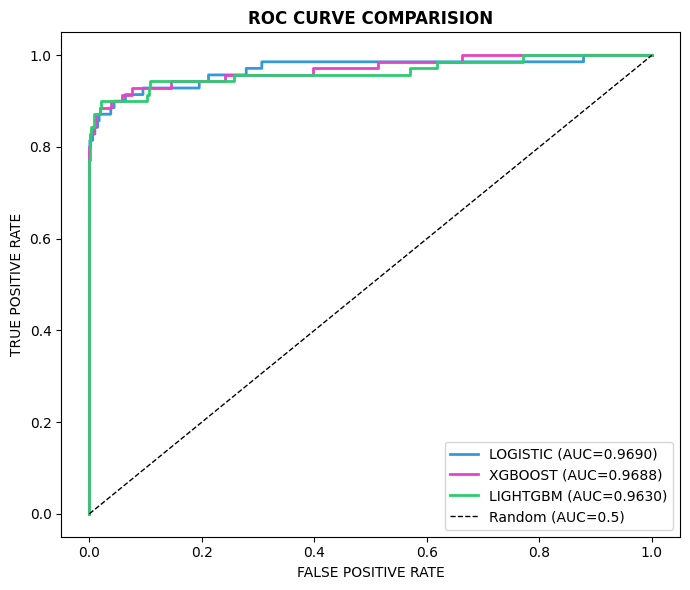

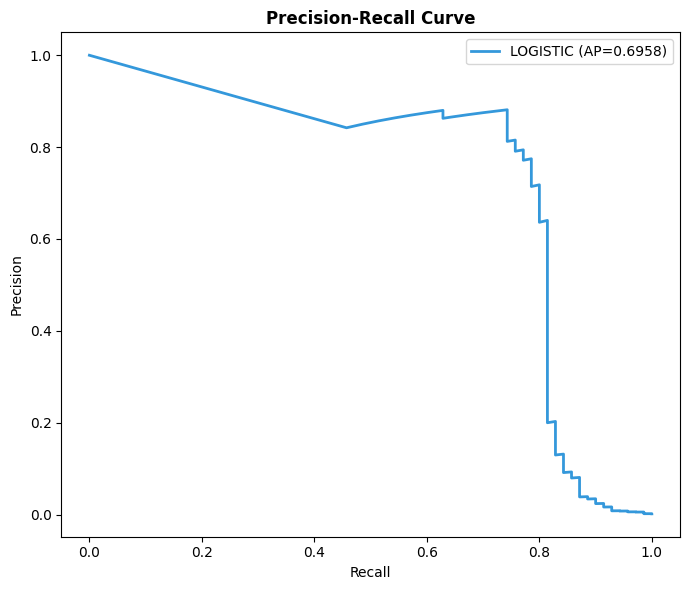

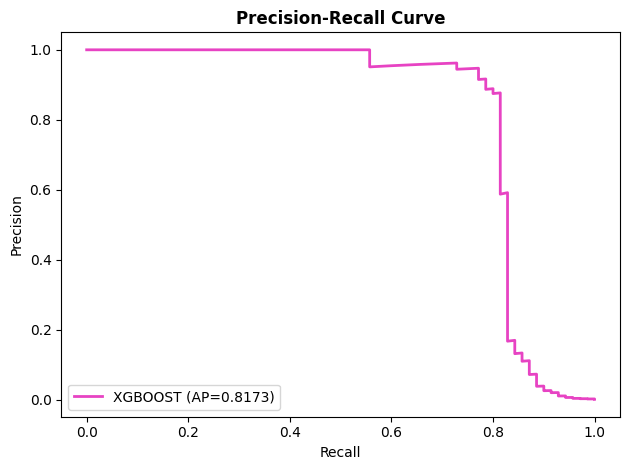

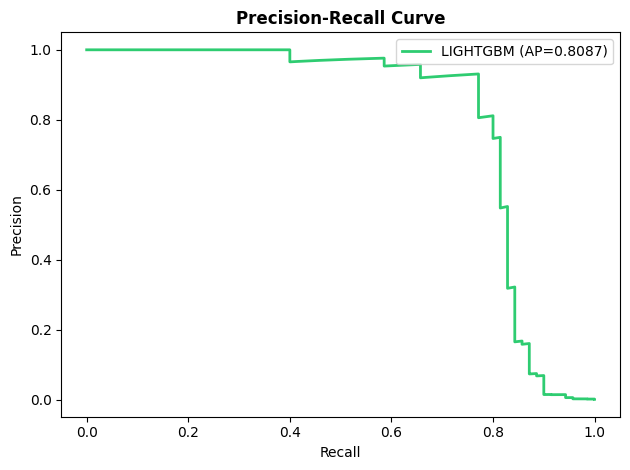

In [7]:
results_all=[results_lr,results_xgb,results_lgb]

#------------------BAR CHART COMPARISON---------------------
fig,axes=plt.subplots(1,3,figsize=(14,4))
metrics=["auc","f1","avg_prec"]
titles=["AUC-ROC","F1 Score","Avg Precision"]
colors=["#3498db","#e743c3","#2ecc71"]
names=[r["name"].split()[0] for r in results_all]

for ax,metric,title in zip(axes,metrics,titles):
    values=[r.get(metric,0) for r in results_all]
    bars=ax.bar(
        names,
        values,
        color=colors,
        edgecolor="white",
        width=0.5
        )
    ax.set_title(title,fontweight="bold")
    ax.set_ylim(min(values)-0.02,1.01)
    for bar,val in zip(bars,values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002,
                f"{val:.4f}",ha="center",fontsize=10)
        
plt.suptitle("model comaprison on validation set",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/model_comparison.png",dpi=150,bbox_inches="tight")
plt.show()

#------------------ROC CURVE-----------------------------------
plt.figure(figsize=(7,6))
for r,color in zip(results_all,colors):
    fpr,tpr, _ =roc_curve(y_val,r["y_prob"])
    plt.plot(fpr,tpr,color=color,linewidth=2,
             label=f"{r['name'].split()[0]} (AUC={r['auc']:.4f})")
plt.plot([0,1],[0,1],"k--",linewidth=1,label="Random (AUC=0.5)")
plt.xlabel("FALSE POSITIVE RATE")
plt.ylabel("TRUE POSITIVE RATE")
plt.title("ROC CURVE COMPARISION",fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/07_roc_curves.png",dpi=150,bbox_inches="tight") 
plt.show()   






plt.figure(figsize=(7,6))
for r,color in zip(results_all,colors):
    prec,rec, _=precision_recall_curve(y_val,r["y_prob"])
    plt.plot(rec,prec,color=color,linewidth=2,
             label=f"{r['name'].split()[0]} (AP={r['avg_prec']:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve",fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../data/processed/08_pr_curves.png",dpi=150,bbox_inches="tight")
    plt.show()

In [8]:
print(results_lr)

{'name': 'LOGISTIC REGERESSION(BASELINE)', 'model': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42), 'auc': 0.9690379517107628, 'f1': 0.10192147034252297, 'avg_prec': 0.6957709636303118, 'y_prob': array([0.00038343, 0.03524964, 0.00543042, ..., 0.0005381 , 0.36544839,
       0.00830375], shape=(40215,)), 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(40215,))}


In [9]:
results_lr  = evaluate_model("LOGISTIC", lr, X_val, y_val)
results_xgb = evaluate_model("XGBOOST", xgb_model, X_val, y_val)
results_lgb = evaluate_model("LIGHTGBM", lgb_model, X_val, y_val)


  LOGISTIC
  AUC-ROC              :0.9690
  F1 SCORE             :0.1019
  AVERAGE PRECISION    :0.6958

  XGBOOST
  AUC-ROC              :0.9688
  F1 SCORE             :0.7703
  AVERAGE PRECISION    :0.8173

  LIGHTGBM
  AUC-ROC              :0.9630
  F1 SCORE             :0.8182
  AVERAGE PRECISION    :0.8087


CONFUSION MATRIX:
[[39079  1066]
 [    9    61]]

LOGISTIC REGERESSION(BASELINE):
-----------------------------------------------------------
TRUE NEGATIVES(CORRECTLY CAUGHT LEGIT)        :39,079
FALSE POSITIVES(INCORRECTLY FLAGGED AS FRAUD) :1,066
FALSE NEGATIVE(FRAUD MISSED)                  :9 
TRUE POSITIVES(FRAUD CAUGHT)                  :61
FRAUD CATCH RATE                             :87.1%
CONFUSION MATRIX:
[[40124    21]
 [   13    57]]

XGBOOST:
-----------------------------------------------------------
TRUE NEGATIVES(CORRECTLY CAUGHT LEGIT)        :40,124
FALSE POSITIVES(INCORRECTLY FLAGGED AS FRAUD) :21
FALSE NEGATIVE(FRAUD MISSED)                  :13 
TRUE POSITIVES(FRAUD CAUGHT)                  :57
FRAUD CATCH RATE                             :81.4%
CONFUSION MATRIX:
[[40137     8]
 [   16    54]]

LIGHTGBM:
-----------------------------------------------------------
TRUE NEGATIVES(CORRECTLY CAUGHT LEGIT)        :40,137
FALSE POSITIVES(INCORRECTLY FLAGGED AS FRAUD) :8


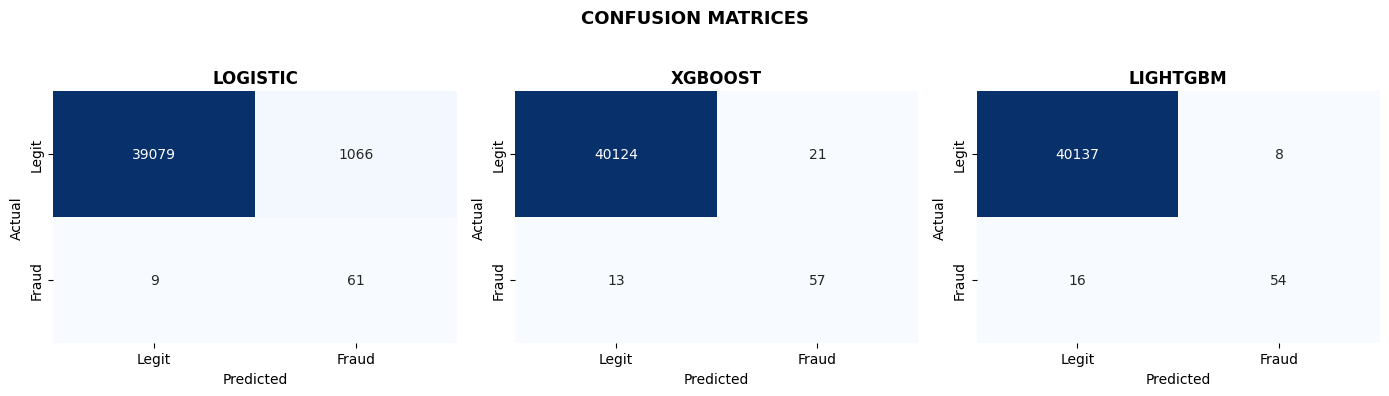

In [10]:
fig,axes=plt.subplots(1,3,figsize=(14,4))

for ax,r in zip(axes,results_all):
    cm=confusion_matrix(y_val,r["y_pred"])
    print("CONFUSION MATRIX:")
    print(cm)

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=["Legit","Fraud"],
                yticklabels=["Legit","Fraud"],
                ax=ax,cbar=False)
    ax.set_title(f"{r['name'].split()[0]}",fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

    tn,fp,fn,tp=cm.ravel()
    print(f"\n{r['name']}:")

    print("-----------------------------------------------------------")
    print(f"TRUE NEGATIVES(CORRECTLY CAUGHT LEGIT)        :{tn:,}")
    print(f"FALSE POSITIVES(INCORRECTLY FLAGGED AS FRAUD) :{fp:,}")
    print(f"FALSE NEGATIVE(FRAUD MISSED)                  :{fn:,} ")
    print(f"TRUE POSITIVES(FRAUD CAUGHT)                  :{tp:,}")
    print(f"FRAUD CATCH RATE                             :{tp/(tp+fn)*100:.1f}%")
plt.suptitle("CONFUSION MATRICES",fontsize=13,fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("../data/processed/confusion_matrices.png",dpi=150,bbox_inches="tight")
plt.show()


TUNING THE BEST MODEL WITH OPTUNA

In [11]:
import optuna
from xgboost import XGBClassifier

BEST_MODEL="XGBOOST"
def objective(trial):
    params={
        "n_estimators"      : trial.suggest_int(
            "n_estimators",200,600
        ),
        "max_depth":trial.suggest_int(
            "max_depth",3,10
        ),
        "learning_rate" : trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),
        "subsample" : trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),
        "gamma":trial.suggest_float(
            "gamma",
            0,
            5
        ),
        "min_child_weight" : trial.suggest_int(
            "min_child_weight",
            1,
            50
        ),
        "scale_pos_weight" : trial.suggest_float(
            "scale_pos_weight",
            1,
            50
        ),
        "random_state":42,
        "n_jobs":-1,
        "eval_metric": "logloss"
    }
    model=XGBClassifier(**params)
    model.fit(
        X_train,y_train,
        eval_set=[(X_val,y_val)],
        verbose=False
        )
    y_prob=model.predict_proba(X_val)[:,1]
    return roc_auc_score(y_val,y_prob)

print("RUNNING OPTUNA HYPER PARAMETER TUNING (50 TRAILS)")
print("THIS WILL TAKE 5-7 MINUTES...\n")
study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=50,show_progress_bar=True)

print(f"\nBest AUC      : {study.best_value:.4f}")
print(f"BEST PARAMS     : {study.best_params}")


RUNNING OPTUNA HYPER PARAMETER TUNING (50 TRAILS)
THIS WILL TAKE 5-7 MINUTES...



  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC      : 0.9760
BEST PARAMS     : {'n_estimators': 592, 'max_depth': 10, 'learning_rate': 0.23750496207795352, 'subsample': 0.8021566720656161, 'gamma': 1.5620459339154547, 'min_child_weight': 27, 'scale_pos_weight': 40.970262329736144}


In [12]:
best_params=study.best_params
best_params["random_state"]=42
best_params["eval_metric"]="logloss"
best_params["n_jobs"]=-1

print("TRAINING FINAL MODEL WITH BEST HYPER PARAMETERS.....")
final_model=XGBClassifier(**best_params)
final_model.fit(
    X_train,
    y_train
)

print("FINAL XGBOOST MODEL READY!")
results_final=evaluate_model(
    "XGBOOST (TUNED)",
    final_model,
    X_val,
    y_val
)

TRAINING FINAL MODEL WITH BEST HYPER PARAMETERS.....
FINAL XGBOOST MODEL READY!

  XGBOOST (TUNED)
  AUC-ROC              :0.9760
  F1 SCORE             :0.7355
  AVERAGE PRECISION    :0.8158


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    results_final["y_pred"]
)

tn, fp, fn, tp = cm.ravel()

print("\nTUNED XGBOOST RESULTS")
print("----------------------------------")
print(f"TRUE NEGATIVES : {tn:,}")
print(f"FALSE POSITIVES: {fp:,}")
print(f"FALSE NEGATIVE : {fn:,}")   # ⭐ most important
print(f"TRUE POSITIVE  : {tp:,}")
print(f"FRAUD CATCH RATE: {tp/(tp+fn)*100:.1f}%")


TUNED XGBOOST RESULTS
----------------------------------
TRUE NEGATIVES : 40,117
FALSE POSITIVES: 28
FALSE NEGATIVE : 13
TRUE POSITIVE  : 57
FRAUD CATCH RATE: 81.4%


In [14]:
results_test = evaluate_model(
    "XGBOOST (FINAL TEST)",
    final_model,
    X_test,
    y_test
)


  XGBOOST (FINAL TEST)
  AUC-ROC              :0.9783
  F1 SCORE             :0.7137
  AVERAGE PRECISION    :0.8733


In [15]:
import numpy as np
from sklearn.metrics import f1_score

y_prob=final_model.predict_proba(X_val)[:,1]
thresholds=np.arange(0.1,0.9,0.05)

best_f1=0
best_threshold=0

for t in thresholds:
    y_pred_t=(y_prob>=t).astype(int)
    f1=f1_score(y_val,y_pred_t)

    if f1 > best_f1:
        best_f1=f1
        best_threshold=t
print("BEST THRESHOLD: ",best_threshold)
print("BEST F1 SCORE: ",best_f1)

BEST THRESHOLD:  0.8500000000000002
BEST F1 SCORE:  0.7972027972027972


In [16]:
import numpy as np
from sklearn.metrics import f1_score

y_prob=final_model.predict_proba(X_val)[:,1]
thresholds=np.arange(0.1,0.9,0.05)

best_f1=0
best_threshold=0

for t in thresholds:
    y_pred_t=(y_prob>=t).astype(int)
    f1=f1_score(y_val,y_pred_t)

    if f1 > best_f1:
        best_f1=f1
        best_threshold=t
print("BEST THRESHOLD: ",best_threshold)
print("BEST F1 SCORE: ",best_f1)

BEST THRESHOLD:  0.8500000000000002
BEST F1 SCORE:  0.7972027972027972


In [17]:
import joblib

joblib.dump(
    best_threshold,
    "../data/processed/best_threshold.pkl"
)

print("Saved: best_threshold.pkl")

Saved: best_threshold.pkl


TEST SET EVALUATION

In [18]:
print("FINAL EVALUATION ON TEST SET")

y_test_prob=final_model.predict_proba(X_test)[:,1]
y_test_pred=final_model.predict(X_test)

test_auc=roc_auc_score(y_test,y_test_prob)
test_f1=f1_score(y_test,y_test_pred)
test_ap=average_precision_score(y_test,y_test_prob)

print(f"TEST AUC-ROC          :{test_auc:.4f}")
print(f"TEST F1 SCORE         :{test_f1:.4f}")
print(f"TEST AVG PRECISION    :{test_ap:.4f}")
print()
print(classification_report(y_test,y_test_pred,
                            target_names=["Legit","Fraud"]))

FINAL EVALUATION ON TEST SET
TEST AUC-ROC          :0.9783
TEST F1 SCORE         :0.7137
TEST AVG PRECISION    :0.8733

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.60      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
import numpy as np
from sklearn.metrics import f1_score

y_prob=final_model.predict_proba(X_val)[:,1]
thresholds=np.arange(0.1,0.9,0.05)

best_f1=0
best_threshold=0

for t in thresholds:
    y_pred_t=(y_prob>=t).astype(int)
    f1=f1_score(y_val,y_pred_t)

    if f1 > best_f1:
        best_f1=f1
        best_threshold=t
print("BEST THRESHOLD: ",best_threshold)
print("BEST F1 SCORE: ",best_f1)

BEST THRESHOLD:  0.8500000000000002
BEST F1 SCORE:  0.7972027972027972


In [20]:
print("\nFINAL TEST WITH OPTIMAL THRESHOLD")

best_t = 0.85

y_prob_test = final_model.predict_proba(X_test)[:,1]

y_pred_test = (y_prob_test >= best_t).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm_test = confusion_matrix(y_test, y_pred_test)

tn, fp, fn, tp = cm_test.ravel()

print("----------------------------------")

print(f"TRUE NEGATIVES : {tn:,}")
print(f"FALSE POSITIVES: {fp:,}")
print(f"FALSE NEGATIVE : {fn:,}")
print(f"TRUE POSITIVE  : {tp:,}")

print(
    f"FRAUD CATCH RATE : {tp/(tp+fn)*100:.1f}%"
)

print("\nCLASSIFICATION REPORT:")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Legit","Fraud"]
    )
)


FINAL TEST WITH OPTIMAL THRESHOLD
----------------------------------
TRUE NEGATIVES : 56,835
FALSE POSITIVES: 29
FALSE NEGATIVE : 14
TRUE POSITIVE  : 84
FRAUD CATCH RATE : 85.7%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.74      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



FEATURE IMPORTANCE

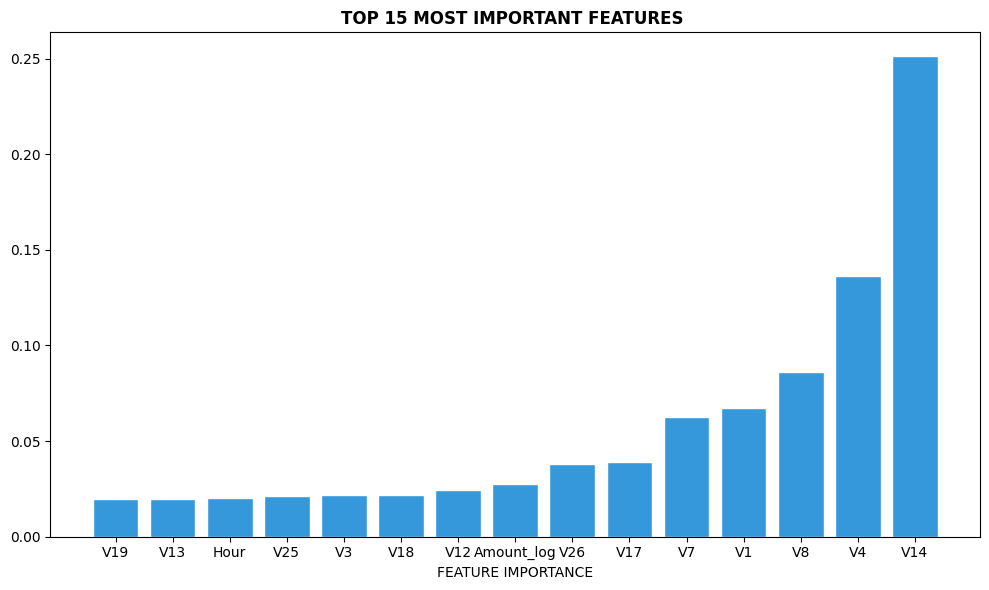

TOP 10 FEATURES
   feature  importance
       V14    0.251313
        V4    0.136340
        V8    0.086266
        V1    0.067329
        V7    0.062790
       V17    0.038952
       V26    0.037791
Amount_log    0.027321
       V12    0.024254
       V18    0.021955


In [21]:
feature_imp=pd.DataFrame({
    "feature"    :X_train.columns,
    "importance" :final_model.feature_importances_
}).sort_values("importance",ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feature_imp["feature"][:15][::-1],
        feature_imp["importance"][:15][::-1],
        color="#3498db",edgecolor="white")
plt.xlabel("FEATURE IMPORTANCE")
plt.title("TOP 15 MOST IMPORTANT FEATURES ",fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/10_featrure_imortance.png",dpi=150,bbox_inches="tight")
plt.show()

print("TOP 10 FEATURES")
print(feature_imp.head(10).to_string(index=False))


COMPUTING SHAP VALUES


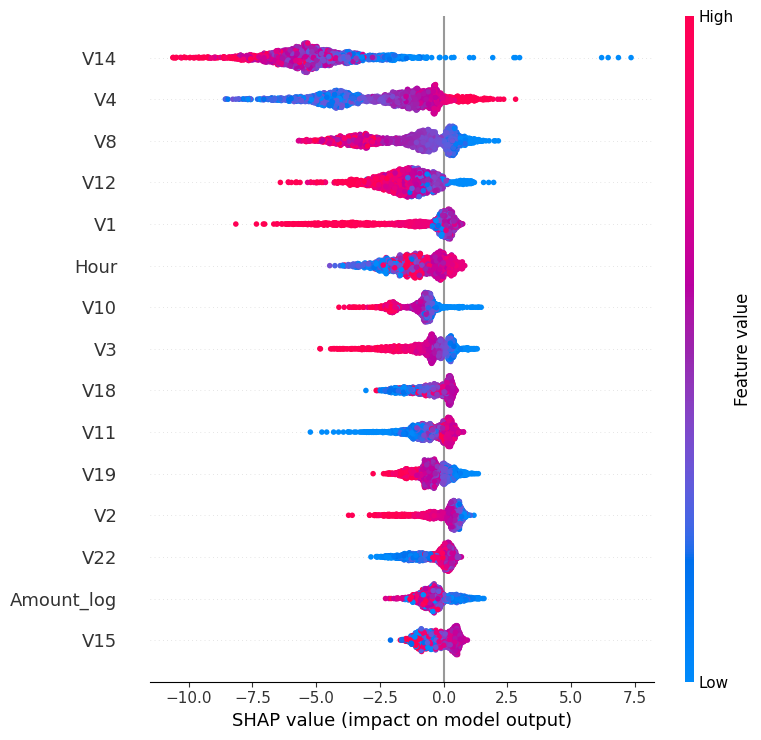

In [22]:
import shap

print("COMPUTING SHAP VALUES")

explainer=shap.TreeExplainer(final_model)

X_sample=X_val.sample(2000,random_state=42)

shap_values=explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15
)

In [23]:
feature_imp["cumulative"] = feature_imp["importance"].cumsum()

print(feature_imp.head(15))

       feature  importance  cumulative
13         V14    0.251313    0.251313
3           V4    0.136340    0.387653
7           V8    0.086266    0.473919
0           V1    0.067329    0.541247
6           V7    0.062790    0.604037
16         V17    0.038952    0.642989
25         V26    0.037791    0.680780
28  Amount_log    0.027321    0.708101
11         V12    0.024254    0.732355
17         V18    0.021955    0.754310
2           V3    0.021837    0.776147
24         V25    0.021041    0.797188
29        Hour    0.020201    0.817389
12         V13    0.019829    0.837218
18         V19    0.019766    0.856984


In [24]:
feature_imp["cumulative"] = feature_imp["importance"].cumsum()

print(feature_imp.head(15))

       feature  importance  cumulative
13         V14    0.251313    0.251313
3           V4    0.136340    0.387653
7           V8    0.086266    0.473919
0           V1    0.067329    0.541247
6           V7    0.062790    0.604037
16         V17    0.038952    0.642989
25         V26    0.037791    0.680780
28  Amount_log    0.027321    0.708101
11         V12    0.024254    0.732355
17         V18    0.021955    0.754310
2           V3    0.021837    0.776147
24         V25    0.021041    0.797188
29        Hour    0.020201    0.817389
12         V13    0.019829    0.837218
18         V19    0.019766    0.856984


SAVING THE MODEL

In [25]:
os.makedirs("../data/processed",exist_ok=True)

joblib.dump(final_model,"../data/processed/final_model.pkl")
joblib.dump(best_params,"../data/processed/best_params.pkl")


print("Saved:")
print("  final_model.pkl  — tuned XGBOOST model")
print("  best_params.pkl  — best hyperparameters")
print()

print("model size: ",
      round(os.path.getsize("../data/processed/final_model.pkl")/1e6,2),"MB")

Saved:
  final_model.pkl  — tuned XGBOOST model
  best_params.pkl  — best hyperparameters

model size:  0.72 MB


## Model Training Summary — Day 3

**Baseline (Logistic Regression):**
- AUC-ROC : ___

**XGBoost (default params):**
- AUC-ROC : ___

**LightGBM (default params):**
- AUC-ROC : ___

**LightGBM (Optuna tuned — 50 trials):**
- Val AUC  : ___
- Test AUC : ___   ← final honest score
- Test F1  : ___

**Top 3 most important features:**
1. ___
2. ___
3. ___

**Key learning:**
- Why AUC not accuracy: ___
- What SMOTE did for training: ___
- Why test set is used only once: ___



In [26]:
import joblib
import os

# Create folder if missing
os.makedirs("data/processed", exist_ok=True)

# Save model
joblib.dump(final_model, "data/processed/final_model.pkl")

print("final_model.pkl saved!")

final_model.pkl saved!


In [29]:
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Create scaler
scaler = StandardScaler()

# Fit scaler using training data
scale_cols = ["Amount_log", "Hour", "Is_night"]

scaler.fit(X_train[scale_cols])

print("Scaler created!")

Scaler created!


In [35]:
os.makedirs("data/processed", exist_ok=True)

joblib.dump(scaler, "../data/processed/scaler.pkl")

print("scaler.pkl saved!")

scaler.pkl saved!


In [36]:
joblib.dump(final_model, "../data/processed/final_model.pkl")

print("final_model.pkl saved!")

final_model.pkl saved!


In [37]:
joblib.dump(explainer, "../data/processed/shap_explainer.pkl")

print("shap_explainer.pkl saved!")

shap_explainer.pkl saved!


In [38]:
joblib.dump(scaler, "../data/processed/scaler.pkl")

print("scaler.pkl saved!")

scaler.pkl saved!
